In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit, cost
from scipy import stats

In [2]:
dataframe = pd.read_csv('data_InconstantBackground.csv', header=0)
dataframe;

FileNotFoundError: [Errno 2] No such file or directory: 'data_InconstantBackground.csv'

In [ ]:
distance = dataframe['# Distance']
for i in range(10):
    print(f"  Distance: {distance[i]:7.4f}")

  Distance:  4.3082
  Distance:  3.9335
  Distance:  4.8559
  Distance:  0.4940
  Distance:  1.6372
  Distance:  7.3720
  Distance:  1.7902
  Distance:  2.5317
  Distance:  0.6765
  Distance:  2.6897


In [ ]:
# Binning parameters:
binning_min  =  0.0
binning_max  = 10.0
Nbins  =  200
binwidth = (binning_max-binning_min) / float(Nbins)
print(f"  The bin width is: {binwidth:5.2f}")

  The bin width is:  0.05


200 200


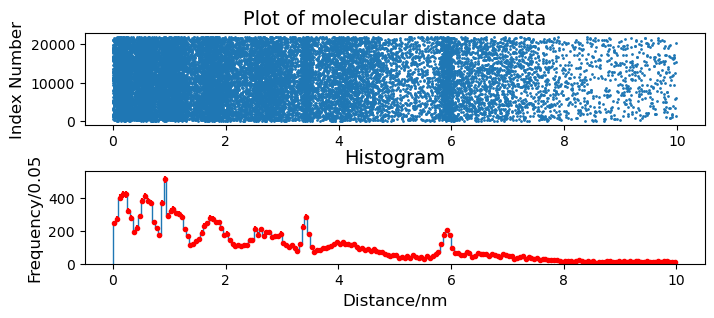

In [ ]:
counts, bin_edges = np.histogram(distance, bins=Nbins, range=(binning_min, binning_max))
unc_count = np.sqrt(counts)
x = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])/2.


fig_data, [ax1,ax2] = plt.subplots(nrows=2, figsize=(8,3), gridspec_kw={'hspace':0.5})

ax1.scatter(distance, range(len(distance)),s=1)
ax1.set_ylabel('Index Number',fontsize=12)
#ax1.set_xlabel('Distance/nm',fontsize=12)
ax1.set_title(f'Plot of molecular distance data',fontsize=14)

print(len(counts),len(x))

#ax2.hist(distance, bins=200, range=(0,10), histtype='stepfilled', label='Histogram of spherical coordinate r')
ax2.stairs(counts,bin_edges)
ax2.set_ylabel(f'Frequency/{binwidth}',fontsize=12)
ax2.set_xlabel('Distance/nm',fontsize=12)
ax2.set_title(f'Histogram',fontsize=14)

ax2.errorbar(x, counts, yerr=unc_count, fmt='.', color='red', label='Data with error bars')
ax2.set_ylabel(f'Frequency/{binwidth}',fontsize=12)
ax2.set_xlabel('Distance/nm',fontsize=12)
ax2.set_title(f'Histogram',fontsize=14)


fig_data.tight_layout;

#fig.savefig(f"5.1DataPlot.png", dpi=600, bbox_inches='tight')


## Test to what extent the background in [8,10] is uniform

In [ ]:
#Gauss peak
def func_gauss(x, N0, mu0, sigma0) :
    norm = binwidth * N0 / np.sqrt(2.0*np.pi) / sigma0
    z = (x-mu0)/sigma0
    return norm * np.exp(-0.5*z*z)

In [ ]:
# fit
def fit_func(x, a,c,x0) :
    return a*(x-x0)**2+c

# Fit the data:
fit_min =   0
fit_max=10
mask_fit = (x > fit_min )*(x < fit_max)  *  (unc_counts>0)

cfit = cost.LeastSquares(x[mask_fit], counts[mask_fit], unc_count[mask_fit] , fit_func)
mfit = Minuit(cfit, c=0)

mfit.fixed["c"]=    False

mfit.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 32.94 (χ²/ndof = 0.8)      │              Nfcn = 13               │
│ EDM = 1.87e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ c    │   12.6    │    0.6    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────┐
│   │     c │
├───┼───────┤
│ c │ 0.316 │
└───┴───────┘

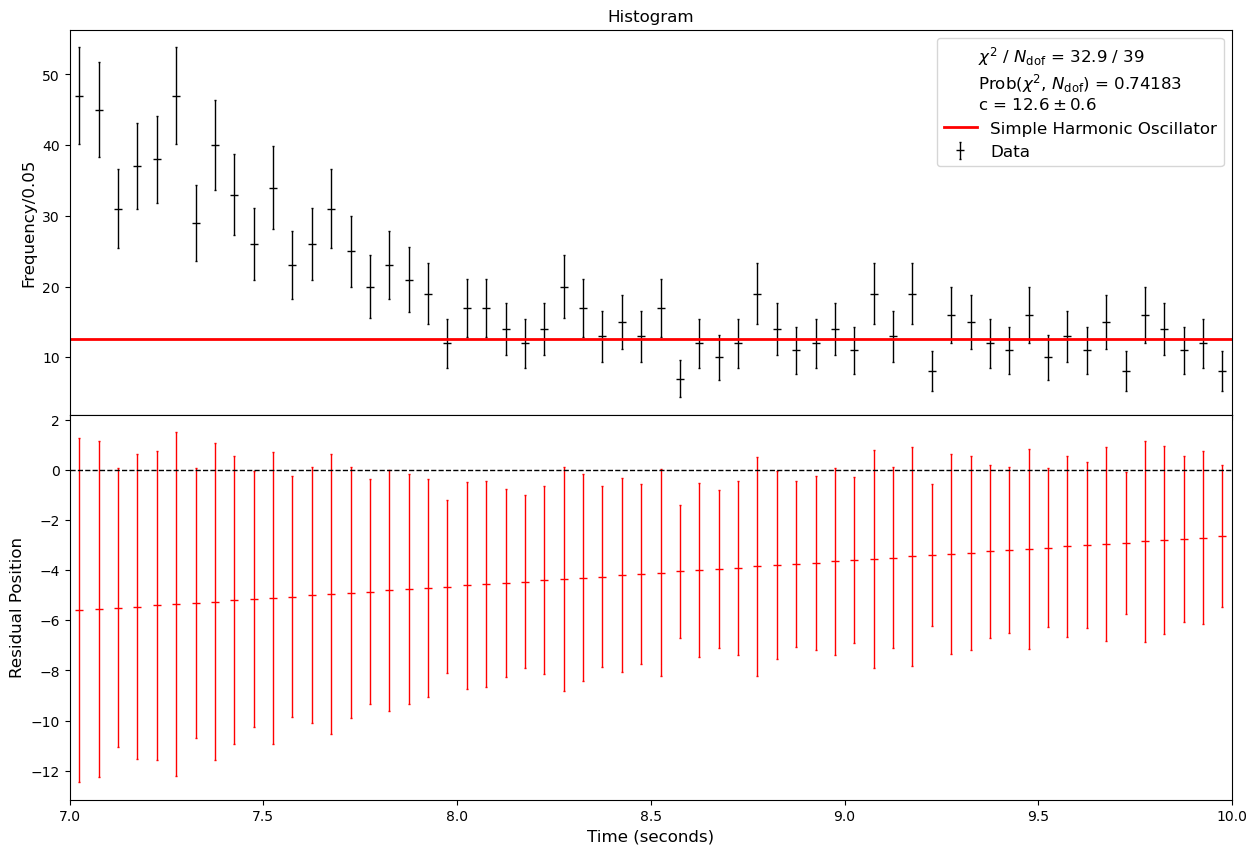

In [ ]:
chi2 = mfit.fval
ndof = len(x[mask_fit])-len(mfit.values[:])
prob = stats.chi2.sf(chi2, ndof)

# Calculate residuals:
residual_counts = counts - fit_func(x, *mfit.values[:])

plot_min =  7
plot_max=   10
mask_plot = (x > plot_min )*(x < plot_max)

#mask_plot = mask_fit


# Plot with common x-axis:
fig, axs = plt.subplots(2, 1, figsize=(15,10), sharex=True)
fig.subplots_adjust(hspace=0)       # Remove vertical space between Axes

# Main plot with fit on top:
axs[0].errorbar(x[mask_plot], counts[mask_plot], unc_count[mask_plot] , fmt='k_', label='Data', ecolor='k', elinewidth=1, capsize=1, capthick=1)
axs[0].set_ylabel(f'Frequency/{binwidth}',fontsize=12)
axs[0].set_title(f'Fit of data and residual plot',fontsize=12)
axs[0].set_xlim(plot_min, plot_max)

# Draw the function on top of the data:
x_fit = np.linspace(plot_min, plot_max, 1000)
y_fit = fit_func(x_fit, *mfit.values[:])
axs[0].plot(x_fit, y_fit, 'r', linewidth=2.0, label='Simple Harmonic Oscillator')

# Put fit info into plot:
fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {prob:.5f}",]
for p, v, e in zip(mfit.parameters, mfit.values[:], mfit.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")
axs[0].legend(title="\n".join(fit_info), fontsize=12, title_fontsize=12, alignment = 'center', loc='upper right');

# Residual plot:
axs[1].errorbar(x[mask_plot], residual_counts[mask_plot], unc_count[mask_plot] , fmt='r_', label='Residuals', ecolor='r', elinewidth=1, capsize=1, capthick=1)
axs[1].set_xlabel("Time (seconds)", fontsize=12)
axs[1].set_ylabel("Residuals = counts - fit", fontsize=12)
axs[1].axhline(0, color='k', linestyle='--', linewidth=1.0)

#fig.savefig("Fit_HarmOsc1.pdf", dpi=600, bbox_inches='tight')